# Seattle City Wage Data - Visualizations

A collection of charts to explore the structure, distribution, and patterns in city employee wages.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

df = pd.read_csv('City_of_Seattle_Wage_Data_20260217.csv')
df.columns = df.columns.str.strip()
df['Hourly Rate'] = pd.to_numeric(df['Hourly Rate'], errors='coerce')
df['Annual Salary Est'] = df['Hourly Rate'] * 2080  # 40 hrs/wk * 52 wks
print(f'Loaded {len(df):,} records')

Loaded 13,893 records


## 1. Overall Wage Distribution with Pay Bands
Where do most city employees fall on the pay scale?

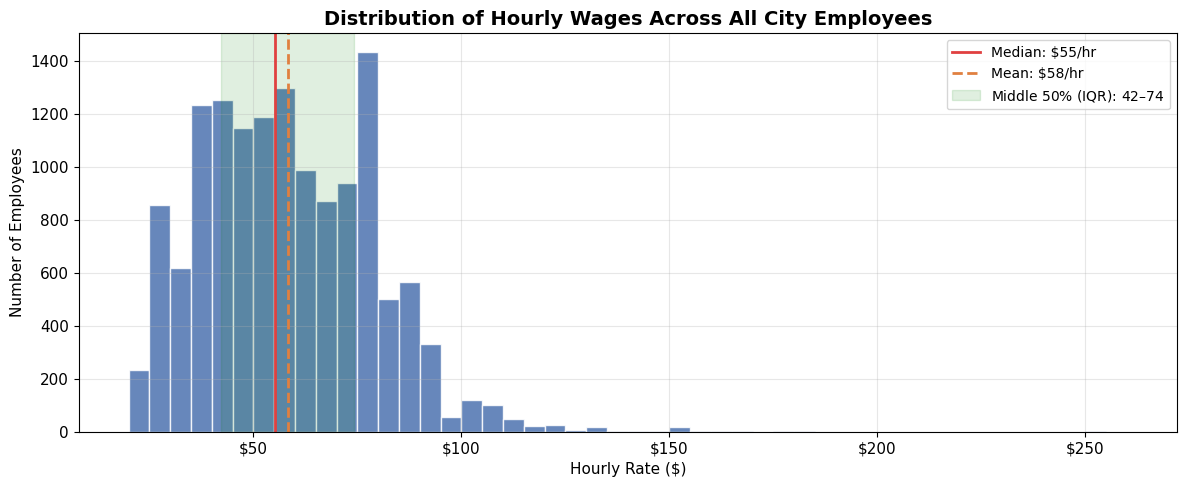

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

bins = np.arange(20, 265, 5)
ax.hist(df['Hourly Rate'], bins=bins, edgecolor='white', color='#4C72B0', alpha=0.85)

mean_val = df['Hourly Rate'].mean()
med_val = df['Hourly Rate'].median()
q25 = df['Hourly Rate'].quantile(0.25)
q75 = df['Hourly Rate'].quantile(0.75)

ax.axvline(med_val, color='#E04040', linewidth=2, linestyle='-', label=f'Median: ${med_val:.0f}/hr')
ax.axvline(mean_val, color='#E08040', linewidth=2, linestyle='--', label=f'Mean: ${mean_val:.0f}/hr')
ax.axvspan(q25, q75, alpha=0.12, color='green', label=f'Middle 50% (IQR): ${q25:.0f}–${q75:.0f}')

ax.set_xlabel('Hourly Rate ($)')
ax.set_ylabel('Number of Employees')
ax.set_title('Distribution of Hourly Wages Across All City Employees', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%g'))
plt.tight_layout()
plt.show()

## 2. Wage Spread by Department
How does pay vary within each department? Departments sorted by median wage.

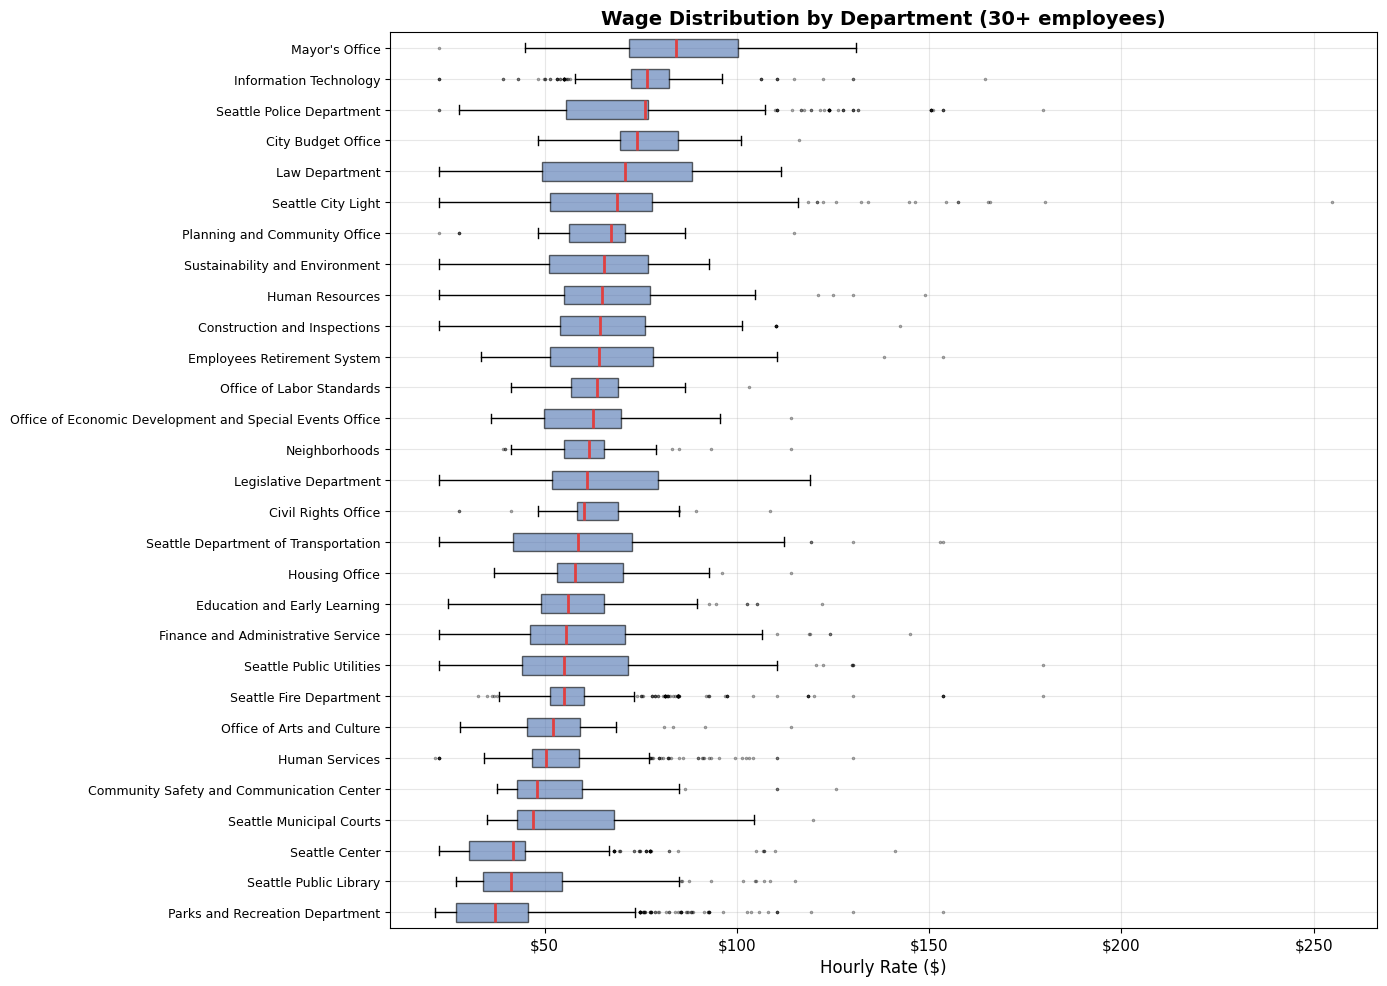

In [3]:
# Keep departments with at least 30 employees for readability
dept_counts = df['Department'].value_counts()
large_depts = dept_counts[dept_counts >= 30].index
df_large = df[df['Department'].isin(large_depts)].copy()

dept_order = df_large.groupby('Department')['Hourly Rate'].median().sort_values().index

fig, ax = plt.subplots(figsize=(14, 10))
data_by_dept = [df_large[df_large['Department'] == d]['Hourly Rate'].dropna().values for d in dept_order]

bp = ax.boxplot(data_by_dept, vert=False, patch_artist=True, widths=0.6,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                medianprops=dict(color='#E04040', linewidth=2),
                flierprops=dict(marker='.', markersize=3, alpha=0.4))

ax.set_yticklabels(dept_order, fontsize=9)
ax.set_xlabel('Hourly Rate ($)', fontsize=12)
ax.set_title('Wage Distribution by Department (30+ employees)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%g'))
plt.tight_layout()
plt.show()

## 3. Department Size vs. Median Pay
Are larger departments higher- or lower-paying?

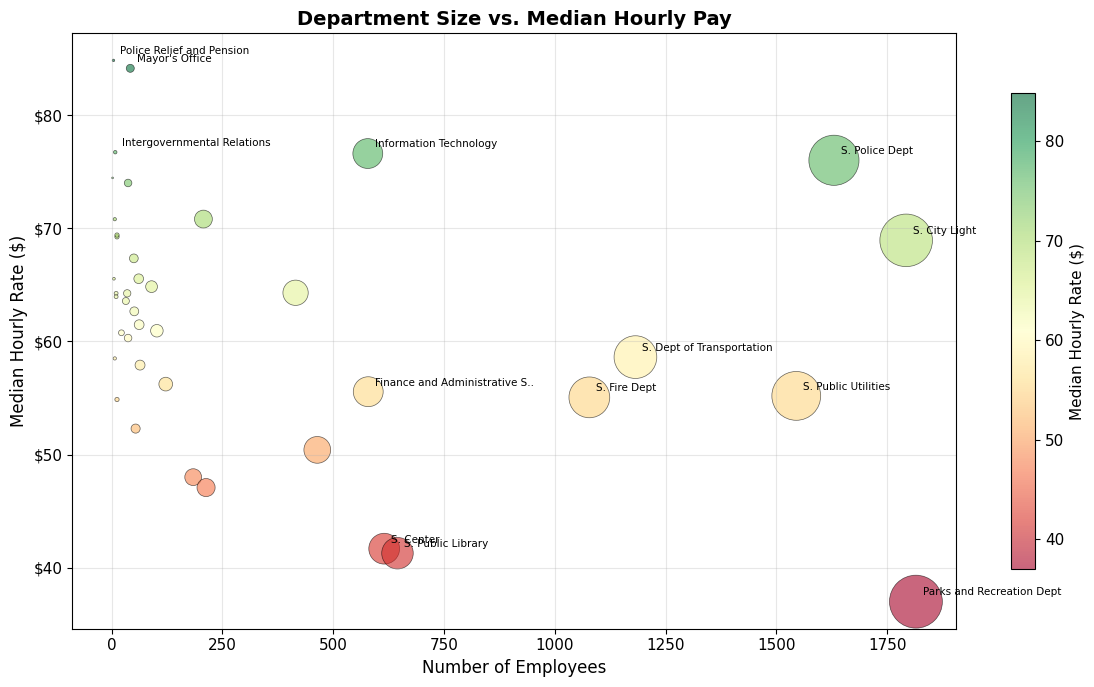

In [4]:
dept_summary = df.groupby('Department')['Hourly Rate'].agg(['count', 'median']).reset_index()
dept_summary.columns = ['Department', 'Employees', 'Median Rate']

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(dept_summary['Employees'], dept_summary['Median Rate'],
                     s=dept_summary['Employees'] * 0.8, alpha=0.6, edgecolors='black', linewidth=0.5,
                     c=dept_summary['Median Rate'], cmap='RdYlGn')

# Label the notable departments
for _, row in dept_summary.iterrows():
    if row['Employees'] > 500 or row['Median Rate'] > 75 or row['Median Rate'] < 40:
        name = row['Department'].replace('Seattle ', 'S. ').replace('Department', 'Dept')
        if len(name) > 30:
            name = name[:28] + '..'
        ax.annotate(name, (row['Employees'], row['Median Rate']),
                    fontsize=7.5, ha='left', va='bottom',
                    xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Number of Employees', fontsize=12)
ax.set_ylabel('Median Hourly Rate ($)', fontsize=12)
ax.set_title('Department Size vs. Median Hourly Pay', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('$%g'))
plt.colorbar(scatter, label='Median Hourly Rate ($)', shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Highest vs. Lowest Paying Job Titles
Comparing the top 15 and bottom 15 job titles by median pay (roles with 10+ employees).

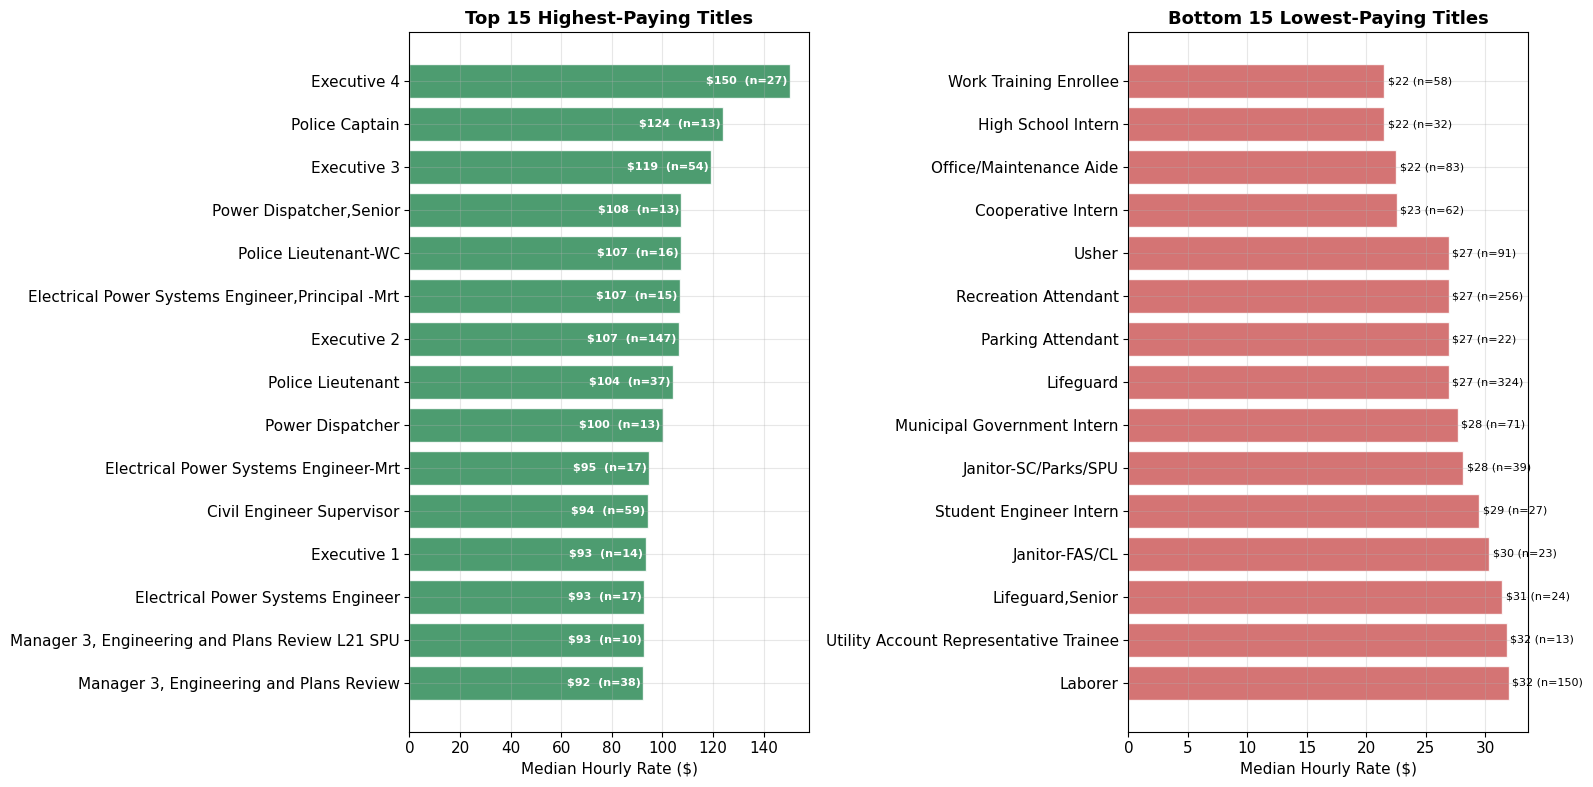

In [5]:
title_stats = df.groupby('Job Title')['Hourly Rate'].agg(['count', 'median']).reset_index()
title_stats.columns = ['Job Title', 'Count', 'Median Rate']
title_common = title_stats[title_stats['Count'] >= 10].copy()

top15 = title_common.nlargest(15, 'Median Rate')
bot15 = title_common.nsmallest(15, 'Median Rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Highest
axes[0].barh(top15['Job Title'], top15['Median Rate'], color='#2E8B57', edgecolor='white', alpha=0.85)
for i, (rate, count) in enumerate(zip(top15['Median Rate'], top15['Count'])):
    axes[0].text(rate - 1, i, f'${rate:.0f}  (n={count})', va='center', ha='right', fontsize=8, color='white', fontweight='bold')
axes[0].set_xlabel('Median Hourly Rate ($)')
axes[0].set_title('Top 15 Highest-Paying Titles', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Lowest
axes[1].barh(bot15.sort_values('Median Rate', ascending=False)['Job Title'],
             bot15.sort_values('Median Rate', ascending=False)['Median Rate'],
             color='#CD5C5C', edgecolor='white', alpha=0.85)
for i, (rate, count) in enumerate(zip(bot15.sort_values('Median Rate', ascending=False)['Median Rate'],
                                       bot15.sort_values('Median Rate', ascending=False)['Count'])):
    axes[1].text(rate + 0.3, i, f'${rate:.0f} (n={count})', va='center', ha='left', fontsize=8)
axes[1].set_xlabel('Median Hourly Rate ($)')
axes[1].set_title('Bottom 15 Lowest-Paying Titles', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Pay Band Heatmap by Department
What share of each department's workforce falls in each pay band?

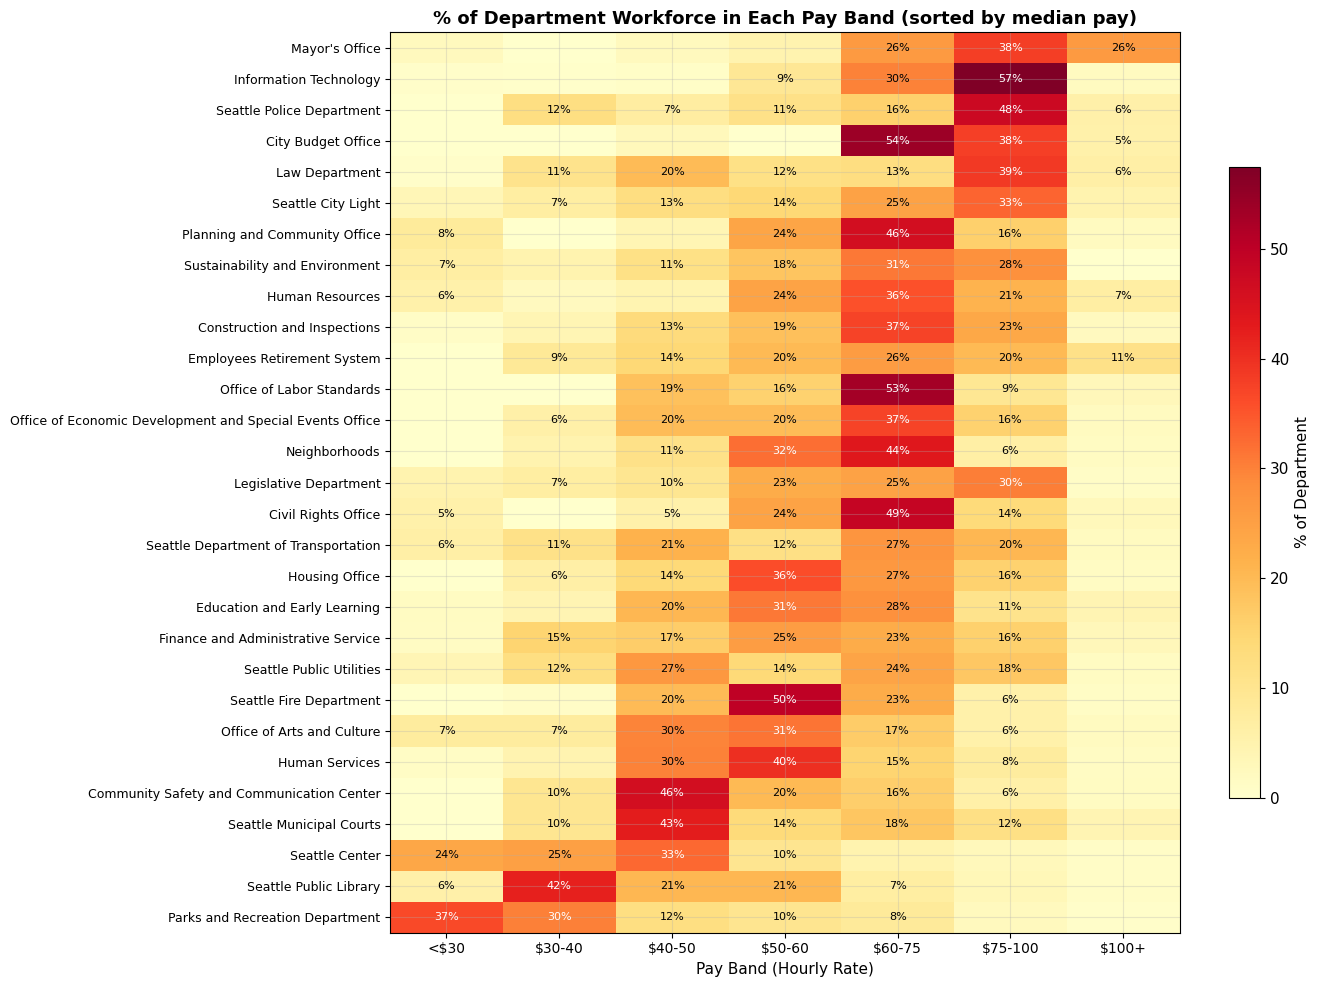

In [6]:
bands = [0, 30, 40, 50, 60, 75, 100, 300]
labels = ['<$30', '$30-40', '$40-50', '$50-60', '$60-75', '$75-100', '$100+']
df_large = df[df['Department'].isin(large_depts)].copy()
df_large['Pay Band'] = pd.cut(df_large['Hourly Rate'], bins=bands, labels=labels)

cross = pd.crosstab(df_large['Department'], df_large['Pay Band'], normalize='index') * 100
dept_med_order = df_large.groupby('Department')['Hourly Rate'].median().sort_values(ascending=False).index
cross = cross.loc[dept_med_order]

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(cross.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks(range(len(cross.index)))
ax.set_yticklabels(cross.index, fontsize=9)

for i in range(len(cross.index)):
    for j in range(len(labels)):
        val = cross.values[i, j]
        if val >= 5:
            color = 'white' if val > 30 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8, color=color)

ax.set_title('% of Department Workforce in Each Pay Band (sorted by median pay)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pay Band (Hourly Rate)')
plt.colorbar(im, label='% of Department', shrink=0.7)
plt.tight_layout()
plt.show()

## 6. Cumulative Distribution — What Percentage Earn Below a Given Rate?
Read this chart as: "X% of employees earn $Y/hr or less."

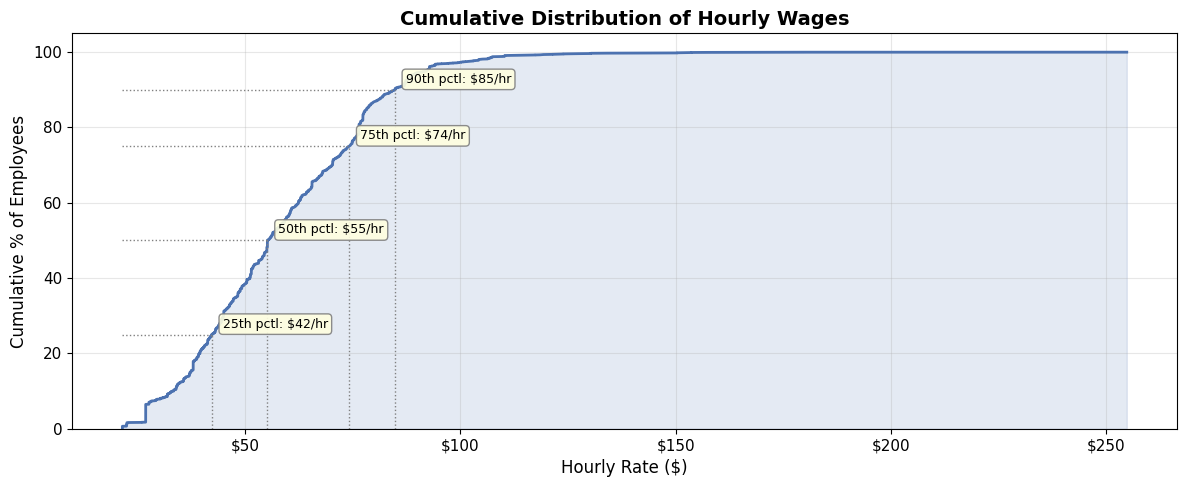

In [7]:
sorted_rates = np.sort(df['Hourly Rate'].dropna())
cumulative_pct = np.arange(1, len(sorted_rates) + 1) / len(sorted_rates) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sorted_rates, cumulative_pct, color='#4C72B0', linewidth=2)
ax.fill_between(sorted_rates, cumulative_pct, alpha=0.15, color='#4C72B0')

for pct in [25, 50, 75, 90]:
    rate = np.percentile(sorted_rates, pct)
    ax.hlines(pct, sorted_rates[0], rate, colors='gray', linestyles=':', linewidth=1)
    ax.vlines(rate, 0, pct, colors='gray', linestyles=':', linewidth=1)
    ax.annotate(f'{pct}th pctl: ${rate:.0f}/hr', (rate, pct),
                xytext=(8, 5), textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.set_xlabel('Hourly Rate ($)', fontsize=12)
ax.set_ylabel('Cumulative % of Employees', fontsize=12)
ax.set_title('Cumulative Distribution of Hourly Wages', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%g'))
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 7. Wage Distributions of the 5 Largest Departments (Overlaid)
Comparing the shape of pay across the biggest city workforces.

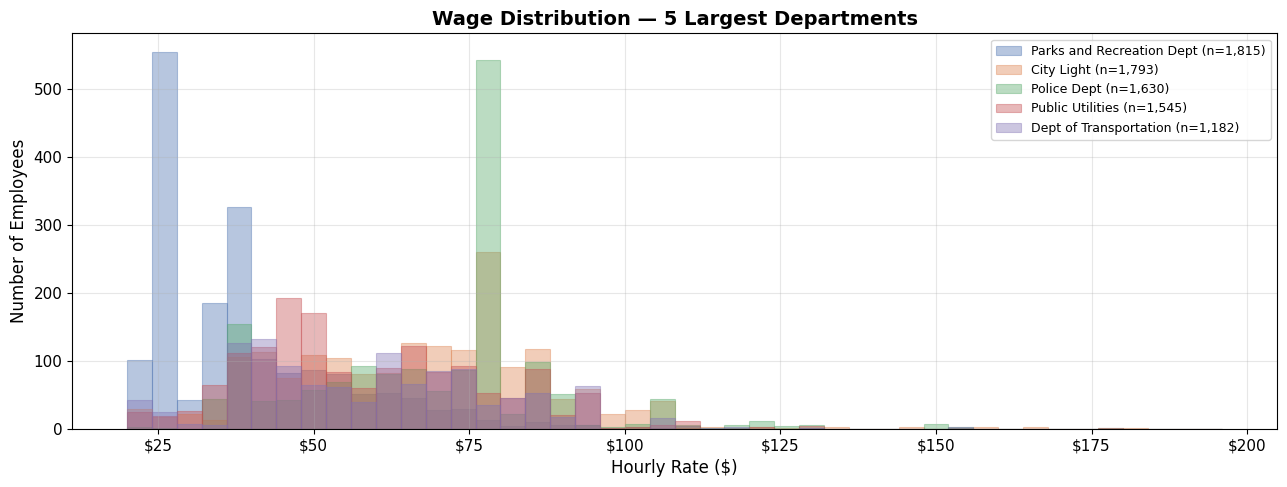

In [8]:
top5_depts = dept_counts.head(5).index
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

fig, ax = plt.subplots(figsize=(13, 5))
bins = np.arange(20, 200, 4)

for dept, color in zip(top5_depts, colors):
    rates = df[df['Department'] == dept]['Hourly Rate'].dropna()
    short_name = dept.replace('Seattle ', '').replace('Department', 'Dept')
    ax.hist(rates, bins=bins, alpha=0.4, label=f'{short_name} (n={len(rates):,})',
            color=color, edgecolor=color, linewidth=0.8)

ax.set_xlabel('Hourly Rate ($)', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.set_title('Wage Distribution — 5 Largest Departments', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%g'))
plt.tight_layout()
plt.show()

## 8. Job Titles with the Widest Pay Ranges
Which roles have the most variation in pay? (titles with 10+ employees)

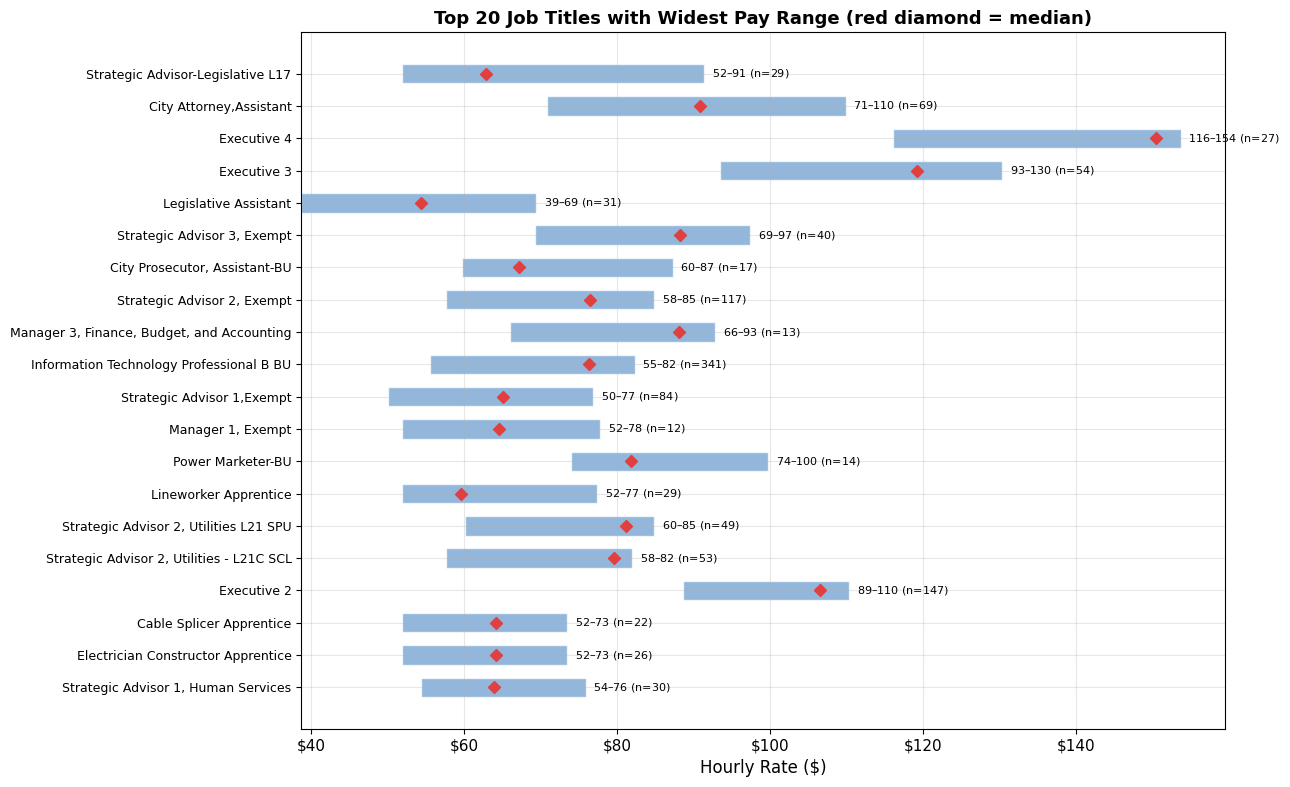

In [9]:
title_spread = df.groupby('Job Title')['Hourly Rate'].agg(['count', 'min', 'max', 'std', 'median']).reset_index()
title_spread.columns = ['Job Title', 'Count', 'Min', 'Max', 'Std Dev', 'Median']
title_spread['Range'] = title_spread['Max'] - title_spread['Min']
title_spread = title_spread[title_spread['Count'] >= 10]
top_spread = title_spread.nlargest(20, 'Range')

fig, ax = plt.subplots(figsize=(13, 8))
y_pos = range(len(top_spread))

ax.barh(y_pos, top_spread['Range'].values, left=top_spread['Min'].values,
        color='#6699CC', edgecolor='white', alpha=0.7, height=0.6)

for i, row in enumerate(top_spread.itertuples()):
    ax.plot(row.Median, i, 'D', color='#E04040', markersize=6, zorder=5)
    ax.text(row.Max + 1, i, f'${row.Min:.0f}–${row.Max:.0f} (n={row.Count})',
            va='center', fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_spread['Job Title'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Hourly Rate ($)', fontsize=12)
ax.set_title('Top 20 Job Titles with Widest Pay Range (red diamond = median)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%g'))
plt.tight_layout()
plt.show()

## 9. Workforce Composition — Department Treemap
Proportional view of how the city's workforce is distributed across departments.

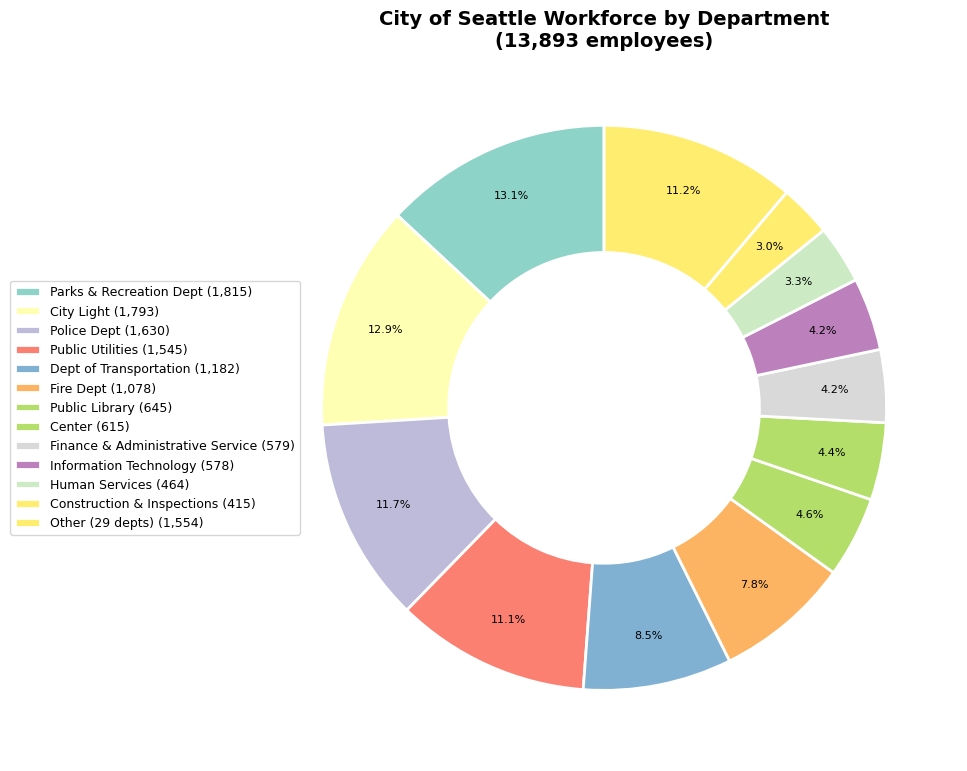

In [10]:
# Treemap-style visualization using nested pie chart
dept_data = df['Department'].value_counts()
top_n = 12
top_depts = dept_data.head(top_n)
other_count = dept_data.iloc[top_n:].sum()
pie_data = pd.concat([top_depts, pd.Series({'Other ({} depts)'.format(len(dept_data) - top_n): other_count})])

fig, ax = plt.subplots(figsize=(10, 10))
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))

wedges, texts, autotexts = ax.pie(
    pie_data.values, labels=None, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)

for t in autotexts:
    t.set_fontsize(8)

short_labels = [d.replace('Seattle ', '').replace('Department', 'Dept').replace(' and ', ' & ')
                for d in pie_data.index]
ax.legend(wedges, [f'{name} ({count:,})' for name, count in zip(short_labels, pie_data.values)],
          loc='center left', bbox_to_anchor=(-0.35, 0.5), fontsize=9)

ax.set_title('City of Seattle Workforce by Department\n(13,893 employees)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Estimated Annual Salary Distribution
Translating hourly rates to approximate annual salaries (assuming 2,080 hrs/year).

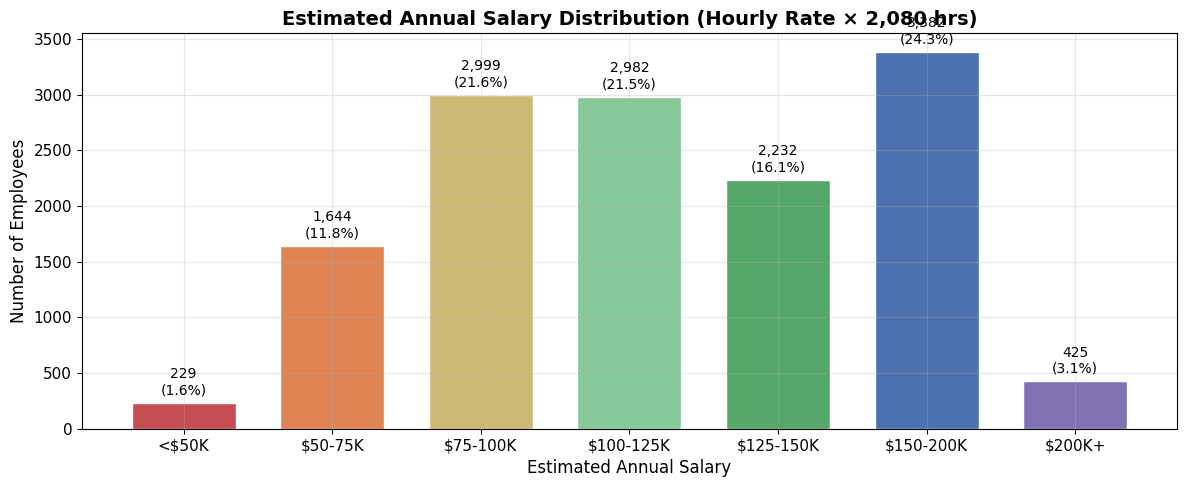

In [11]:
salary_bands = [0, 50000, 75000, 100000, 125000, 150000, 200000, 600000]
salary_labels = ['<$50K', '$50-75K', '$75-100K', '$100-125K', '$125-150K', '$150-200K', '$200K+']
df['Salary Band'] = pd.cut(df['Annual Salary Est'], bins=salary_bands, labels=salary_labels)

band_counts = df['Salary Band'].value_counts().reindex(salary_labels)
band_pcts = (band_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#C44E52', '#DD8452', '#CCB974', '#88C999', '#55A868', '#4C72B0', '#8172B3']
bars = ax.bar(salary_labels, band_counts.values, color=bar_colors, edgecolor='white', width=0.7)

for bar, pct, count in zip(bars, band_pcts.values, band_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}\n({pct}%)', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Estimated Annual Salary', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.set_title('Estimated Annual Salary Distribution (Hourly Rate × 2,080 hrs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()